# Demo on mobility-CIR-CFR

- This code demonstrates how channel frequency response (CFR) and channel impulse response (CIR) changes as the transceivers move.
- The captured CFR and CIR can be animated.

In [129]:
import sionna.rt

import time
import os
import re

import cv2
from PIL import Image

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial, SceneObject

import scipy.signal
import scipy.linalg

In [130]:
# scene = load_scene("../assets/ssm-scene/ssm-scene-v2_3.xml")
scene = load_scene(sionna.rt.scene.simple_street_canyon_with_cars, merge_shapes=False)

scene.frequency = 5e9

# BS (TX): 32-element ULA (Uniform Linear Array), SINGLE polarization.
# A ULA (not a square UPA) is used so that each antenna index maps onto a
# single physical coordinate along one line - i.e. a literal 1-D "space"
# axis, matching the antenna_channel_matrix cube requested below. Single
# polarization ("V") is used so each entry of num_tx_ant corresponds to
# exactly ONE physical antenna location (dual-pol would put 2 logical
# antennas - V and H - at the same physical spot, breaking the 1
# antenna <-> 1 space-slot mapping).
num_bs_antennas = 32
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=num_bs_antennas,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

# UE (RX): single antenna (1x1) - typical for a handset/simple UE, and
# keeps the channel a clean (space, frequency) MATRIX per snapshot
# instead of a (rx_ant, tx_ant, frequency) tensor.
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             pattern="iso",
                             polarization="V")
try:
    scene.synthetic_array = True
except Exception:
    pass


bs_pos = [-25.0, 0.0, 15.0]
tx = Transmitter(name="bs", position=bs_pos)
scene.add(tx)
# car_2 mesh는 그대로 두고 (장애물/반사체 역할)
car_2 = scene.get("car_2")
car_2.position += [0, 20, 0]
car_2.orientation = [np.pi/2, 0, 0]

# UE(안테나)는 별도 이름으로 생성, car_2 위치를 따라가도록 설정
# position에는 tensor가 아니라 plain list를 넣어주는 게 안전합니다
car_2_pos = car_2.position.numpy()[:, 0]          # [x, y, z]
ue_pos = car_2_pos + [0, 0, 1.0]                    # 차 지붕 위 1m에 안테나 마운트
ue_start_pos = ue_pos.copy()  # 시뮬레이션 시작 시점의 UE 위치

vel = -20
velocity=np.array([0, vel, 0])
rx = Receiver(name="ue", position=ue_pos.tolist(), orientation=car_2.orientation)

scene.add(rx)

scene.preview();


In [131]:
# 15 kHz subcarrier spacing.
# 14 OFDM symbols per slot.
# 25RB * 12 subcarriers per RB = 300 subcarriers per slot.
subcarrier_spacing = 15e3
num_subcarriers = 300
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)
num_ofdm_symbols = 14
num_paths = 5 # Desired number of paths of CIR reconstruction.

bandwidth = num_subcarriers * subcarrier_spacing
print(f"Total bandwidth: {bandwidth / 1e6} MHz")
print(f"Time resolution: {1e6/bandwidth:.3f} us")

p_solver = PathSolver()

Total bandwidth: 4.5 MHz
Time resolution: 0.222 us


In [132]:
paths = p_solver(scene=scene,
                 max_depth=2,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=True,
                 seed=1)

## Antenna Channel Matrix Cube: Angular Frequency × Time × Space

요청하신 3개 조건에 대한 검토 결과입니다.

1. **UE(rx) array = 1×1**: 그대로 타당합니다. 단일 안테나 UE는 흔한 설정이고, 무엇보다
   채널을 `(space, frequency)` **순수 2차원 행렬**로 다룰 수 있게 해줘서 이번 cube 시각화와
   잘 맞습니다 (rx 안테나가 여러 개면 `(rx_ant, tx_ant, frequency)` 3차원 텐서가 되어 "행렬"이라는
   표현과 맞지 않게 됩니다).

2. **BS(tx) array ≥ 32**: 개수 조건은 타당하지만, 배열 형태는 **8×4 UPA + 이중편파(VH)** 대신
   **32-element ULA(Uniform Linear Array) + 단일편파(V)** 로 바꿨습니다. 이유는:
   - 그림에서 "space" 축은 **하나의 직선(1차원) 물리 좌표**로 그려져 있는데, 정사각형 UPA(8×4)의
     안테나들은 2차원 평면 위에 흩어져 있어서 인덱스 하나로 "space" 축에 매끄럽게 대응시킬 수
     없습니다. ULA는 안테나가 실제로 한 줄로 배치되므로 antenna index가 곧 물리적 위치(공간
     좌표)와 1:1로 대응됩니다.
   - 이중편파(VH)를 쓰면 같은 물리적 위치에 V/H 두 개의 논리적 안테나가 겹쳐서, "안테나 1개 =
     공간상 1개 지점"이라는 전제가 깨집니다. 그래서 단일편파(V)로 바꿨습니다.

3. **Cube plot**: 아래에서 각 macro step(t, UE 위치 p_t)마다 `paths.cfr()`로
   **(space=32개 tx 안테나, frequency=264개 subcarrier)** 형태의 순간 "antenna channel matrix"를
   계산하고, 이를 시간축(t)에 대해 쌓아서 `(t, space, f)` 3차원 텐서를 만듭니다. 이후 특정
   `(t_0, p_0)` 지점의 슬라이스를 그림처럼 3D 박스 안에 색으로 채운 평면으로 표시합니다.
   주파수 축은 요청하신 대로 **각주파수(angular frequency) ω = 2πΔf** (baseband, 반송파
   기준 오프셋)로 표시했습니다.


In [133]:
# ------------------------------------------------------------
# Build the (time, space, frequency) antenna-channel-matrix tensor.
# One "antenna channel matrix" (space x frequency, complex) per macro
# step t (= one UE position p_t along the trajectory).
# ------------------------------------------------------------
num_time_steps = 20
velocity = np.array([0, vel, 0])
time_step_length = 0.1

car_2_traj_x = np.linspace(car_2_pos[0], car_2_pos[0] + 0, num_time_steps)
car_2_traj_y = np.linspace(car_2_pos[1], car_2_pos[1] - 20, num_time_steps)
car_2_traj_z = np.linspace(car_2_pos[2], car_2_pos[2] + 0, num_time_steps)
car_2_traj = np.stack([car_2_traj_x, car_2_traj_y, car_2_traj_z], axis=1)

target_rx, target_rx_ant = 0, 0  # single UE antenna -> only index 0 exists

H_cube = np.zeros((num_time_steps, num_bs_antennas, num_subcarriers), dtype=np.complex64)

for t in range(num_time_steps):
    scene.get("car_2").position = car_2_traj[t].tolist()
    scene.get("ue").position = (car_2_traj[t] + [0, 0, 1.0]).tolist()

    paths = p_solver(scene=scene,
                      max_depth=2,
                      los=True,
                      specular_reflection=True,
                      diffuse_reflection=False,
                      refraction=True,
                      diffraction=True,
                      synthetic_array=True,
                      seed=1)

    cfr = paths.cfr(frequencies=frequencies,
                     sampling_frequency=subcarrier_spacing,
                     num_time_steps=1,
                     normalize_delays=False,
                     normalize=True,
                     out_type="numpy")
    # cfr shape: (num_rx, num_rx_ant, num_tx, num_tx_ant, num_subcarriers, 1)
    H_t = cfr[target_rx, target_rx_ant, 0, :, 0, :]  # (num_bs_antennas, num_subcarriers) - FIX: freq axis is LAST, not 2nd-to-last
    H_cube[t] = H_t

print("H_cube shape (time, space=tx_antenna, frequency):", H_cube.shape)


H_cube shape (time, space=tx_antenna, frequency): (20, 32, 300)


### 축 이름 변경에 대한 검토

요청하신 3개 이름 변경 중 2개는 그대로 적용했고, 1개는 수정했습니다.

- **space → antenna index**: 타당합니다. `antenna_pos`(물리적 거리, m)는
  `0.5λ × antenna_idx`로 안테나 인덱스에 대한 **선형 재척도(rescaling)**​일 뿐이라, 그냥
  정수 인덱스로 축을 바꿔도 정보 손실이나 오류가 없습니다.
- **angular frequency → subcarrier**: 타당합니다. `omega = 2π × subcarrier_spacing × (k - N/2)`
  역시 subcarrier index `k`에 대한 선형 함수라서, subcarrier index로 축을 바꿔도 동일한 정보입니다.
- **time → OFDM symbol**: **이건 틀렸습니다.** 이 cube의 x축(`t`)은 UE가 실제로 20m를 이동하는
  **macro mobility step**(한 스텝 = 0.1s, 매 스텝마다 path를 재트레이싱)입니다. 반면 "OFDM symbol"은
  앞선 CFR heatmap / PDP-phase 섹션에서 쓰인 **fine timestep**(한 스텝 = 1/15kHz ≈ 66.7μs,
  path를 재트레이싱하지 않고 Doppler만 해석적으로 적용)을 가리킵니다. 두 축은 스케일이 약
  1500배 차이 나는 서로 다른 시간축이라, `t`를 "OFDM symbol"이라고 부르면 둘을 혼동하게 됩니다.
  그래서 x축 라벨은 "macro mobility step (≈ UE position index)"로 명확히 남겨뒀습니다.
  정말로 OFDM symbol 단위의 cube를 원하시면, `H_cube`를 지금처럼 macro step으로 쌓는 대신
  **하나의 위치에 고정한 채 fine timestep(Doppler)으로 쌓아야** 해서 별도로 다시 만들어드릴 수
  있습니다.


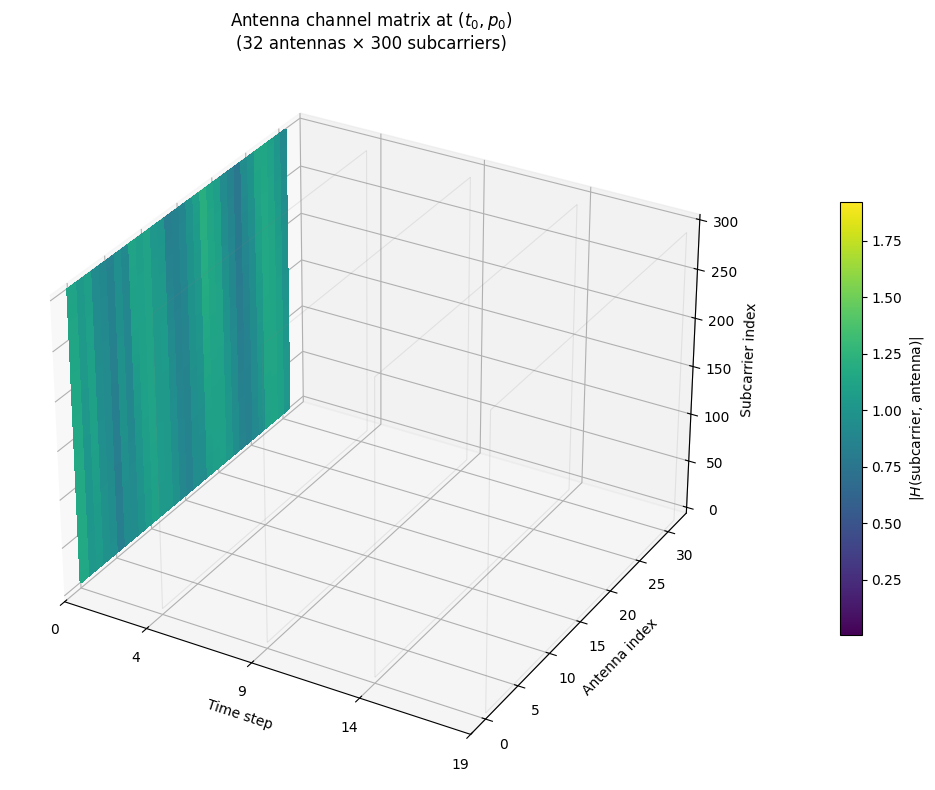

In [134]:
# ------------------------------------------------------------
# 3D cube: highlight the antenna channel matrix slice at (t_k, p_k)
# Wrapped in a function so the same plot can be (a) shown once for a
# chosen t, or (b) generated for every t to build a video (see below).
# ------------------------------------------------------------
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib import cm

# NOTE on axis choice:
# - "subcarrier index" and "antenna index" are just a linear rescaling of
#   angular-frequency (omega = 2*pi*subcarrier_spacing*(k - N/2)) and
#   physical antenna position (0.5*wavelength*antenna_index) respectively,
#   so relabeling to plain indices is a valid, equivalent axis choice.
# - The x-axis stays the MACRO mobility step (NOT "OFDM symbol"): OFDM
#   symbols are the FINE (~66.7us) timestep used in the CFR-heatmap/PDP
#   sections elsewhere in this notebook, while this cube's x-axis is the
#   COARSE (~0.1s) mobility step at which the scene is physically moved
#   and re-traced. Mislabeling it "OFDM symbol" would conflate two
#   different timescales.
subcarrier_idx = np.arange(num_subcarriers)
antenna_idx = np.arange(num_bs_antennas)

# Fix the color scale globally (across all t) so frames don't jitter / are comparable.
_global_norm = plt.Normalize(np.abs(H_cube).min(), np.abs(H_cube).max())

Space_grid, Omega_grid = np.meshgrid(antenna_idx, subcarrier_idx, indexing="ij")


def plot_channel_matrix_slice(t_highlight, save_path=None):
    """Render the antenna-channel-matrix cube with the slice at macro
    step `t_highlight` highlighted. If `save_path` is given, save to
    disk and close the figure (for batch/video generation) instead of
    displaying it inline.
    """
    mag_slice = np.abs(H_cube[t_highlight])  # (space, frequency)
    colors = cm.viridis(_global_norm(mag_slice))

    T_grid = np.full_like(Space_grid, t_highlight, dtype=float)

    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")

    # Highlighted antenna-channel-matrix slice at (t_highlight, p_{t_highlight})
    ax.plot_surface(T_grid, Space_grid, Omega_grid,
                     facecolors=colors, rstride=1, cstride=4,
                     shade=False, antialiased=False, zorder=5)

    # Faint wireframes at a few other timesteps, to suggest the full (t, space, f) cube
    for t_ref in np.linspace(0, num_time_steps - 1, 5, dtype=int):
        if t_ref == t_highlight:
            continue
        T_ref = np.full((2, 2), t_ref, dtype=float)
        S_ref = np.array([[antenna_idx[0], antenna_idx[-1]], [antenna_idx[0], antenna_idx[-1]]])
        O_ref = np.array([[subcarrier_idx[0], subcarrier_idx[0]], [subcarrier_idx[-1], subcarrier_idx[-1]]])
        ax.plot_wireframe(T_ref, S_ref, O_ref, color="gray", alpha=0.15, linewidth=0.8)

    mappable = cm.ScalarMappable(norm=_global_norm, cmap="viridis")
    mappable.set_array(np.abs(H_cube))
    fig.colorbar(mappable, ax=ax, shrink=0.6, pad=0.1, label=r"$|H(\mathrm{subcarrier}, \mathrm{antenna})|$")

    ax.set_xlabel("Time step") # (macro mobility step $t$ \u2248 UE position index)
    ax.set_ylabel("Antenna index") #(BS ULA, 0-31)
    ax.set_zlabel("Subcarrier index")
    ax.set_title(
        f"Antenna channel matrix at $(t_{{{t_highlight}}}, p_{{{t_highlight}}})$\n"
        f"({num_bs_antennas} antennas \u00d7 {num_subcarriers} subcarriers)"
    )
    ax.set_xlim(0, num_time_steps - 1)
    ax.set_xticks(np.linspace(0, num_time_steps - 1, 5, dtype=int))

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
        plt.close(fig)
    else:
        plt.show()


# Show a single slice, e.g. t_0
plot_channel_matrix_slice(t_highlight=0)


In [135]:
def plot_multiple_channel_matrices(t_list, save_path=None):
    """
    Render the antenna-channel-matrix cube with multiple slices 
    at the macro steps specified in `t_list` drawn simultaneously.
    """
    fig = plt.figure(figsize=(11, 8))
    ax = fig.add_subplot(111, projection="3d")
    
    # Iterate through the requested timesteps and plot each surface
    for t_idx in t_list:
        mag_slice = np.abs(H_cube[t_idx])  # (space, frequency)
        colors = cm.viridis(_global_norm(mag_slice))

        T_grid = np.full_like(Space_grid, t_idx, dtype=float)

        ax.plot_surface(T_grid, Space_grid, Omega_grid,
                            facecolors=colors, rstride=1, cstride=4,
                            shade=False, antialiased=False, zorder=5)

    # Add colorbar
    mappable = cm.ScalarMappable(norm=_global_norm, cmap="viridis")
    mappable.set_array(np.abs(H_cube))
    fig.colorbar(mappable, ax=ax, shrink=0.6, pad=0.1, label=r"$|H(\mathrm{subcarrier}, \mathrm{antenna})|$")

    # Set labels and formatting
    ax.set_xlabel("Time step")
    ax.set_ylabel("Antenna index")
    ax.set_zlabel("Subcarrier index")
    ax.set_title(
        f"Antenna channel matrices\n"
        f"({num_bs_antennas} antennas $\\times$ {num_subcarriers} subcarriers)"
    )
    ax.set_xlim(0, num_time_steps - 1)
    ax.set_xticks(np.linspace(0, num_time_steps - 1, 5, dtype=int))

    plt.tight_layout()
    
    # Save or show
    if save_path is not None:
        plt.savefig(save_path)
        plt.close(fig)
        print(f"Saved multiple slices to {save_path}")
    else:
        plt.show()

# ---------------------------------------------------------
# Run the new function for t = [0, 5, 10, 15] and save it
# ---------------------------------------------------------
plot_multiple_channel_matrices(
    t_list=[0, 5, 10, 15], 
    save_path="new_demo_figs_cube.png"
)

Saved multiple slices to new_demo_figs_cube.png


### 왜 초반 time step은 안테나별로 색이 다르고, 후반은 다 같은 색인가?

`t=2`처럼 안테나 축으로 뚜렷한 줄무늬가 보이는 프레임과, `t=18`처럼 완전히 균일한 프레임을
비교해보면, **"유효 경로가 몇 개 살아있는가"** 로 설명됩니다.

- 지금 `H_cube`를 만드는 PathSolver 설정은 `los=True, specular_reflection=False,
  diffuse_reflection=False, refraction=True, diffraction=True` 입니다. 즉 반사는 꺼져 있고,
  LoS + 굴절 + 회절만 허용됩니다.
- **경로가 2개 이상**(예: LoS + 모서리 회절) 존재하면, 서로 다른 도래각(AoA)으로 32개 안테나에
  도착해서 안테나 위치마다 위상차가 달라지고 **보강/상쇄 간섭 → 안테나 축으로 magnitude가
  출렁입니다** (공간적 fading). 지난번 주파수 축 리플과 완전히 같은 원리이고, 축만 "주파수 →
  공간"으로 바뀐 것입니다.
- **경로가 딱 1개(주로 LoS)만 남으면**, 간섭할 상대가 없으니 $|a\cdot e^{{jk\cdot d_i}}|=|a|$로
  **모든 안테나에서 magnitude가 동일**해집니다 (위상만 선형으로 회전, 크기는 불변) - 그리고
  같은 이유로 주파수 축도 flat해집니다. 즉 **"공간으로 flat" 과 "주파수로 flat"은 같은 근본
  원인(유효 경로 개수 1개)에서 함께 나타나는 두 증상**입니다.

UE가 이동 경로 초반에는 교차로/모서리 근처를 지나며 회절 경로가 추가로 잡히다가, 후반에는
곧게 뻗은 구간(회절시켜줄 모서리도, 굴절시켜줄 재질도 근처에 없는 구간)으로 들어가면서
LoS 단일 경로만 남았을 가능성이 높습니다. 아래 셀에서 모든 macro step에 대해 실제 유효 경로
수와 안테나 축 변동성을 함께 출력해서 이 가설을 직접 확인합니다.


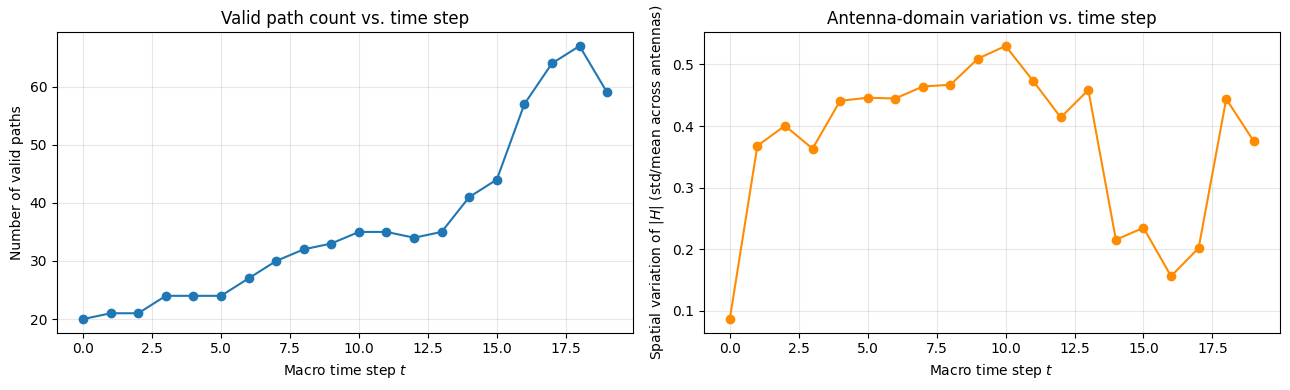

t : num_valid_paths : spatial CV (std/mean across 32 antennas)
 0 : 20 : 0.0868
 1 : 21 : 0.3679
 2 : 21 : 0.4006
 3 : 24 : 0.3633
 4 : 24 : 0.4409
 5 : 24 : 0.4460
 6 : 27 : 0.4447
 7 : 30 : 0.4642
 8 : 32 : 0.4670
 9 : 33 : 0.5095
10 : 35 : 0.5299
11 : 35 : 0.4732
12 : 34 : 0.4140
13 : 35 : 0.4586
14 : 41 : 0.2156
15 : 44 : 0.2350
16 : 57 : 0.1564
17 : 64 : 0.2021
18 : 67 : 0.4440
19 : 59 : 0.3753


In [136]:
# ------------------------------------------------------------
# Diagnostic: valid path count & antenna-domain (spatial) variation
# vs macro time step, to confirm that "flat antenna axis" <=> "few/1
# valid path(s)" and vice versa.
# ------------------------------------------------------------
path_counts = []
spatial_cv = []  # coefficient of variation (std/mean) of |H| across antennas

for t in range(num_time_steps):
    scene.get("car_2").position = car_2_traj[t].tolist()
    scene.get("ue").position = (car_2_traj[t] + [0, 0, 1.0]).tolist()

    paths_t = p_solver(scene=scene,
                        max_depth=2,
                        los=True,
                        specular_reflection=True,
                        diffuse_reflection=False,
                        refraction=True,
                        diffraction=True,
                        synthetic_array=True,
                        seed=1)

    cir_t = paths_t.cir(sampling_frequency=subcarrier_spacing,
                         num_time_steps=1,
                         normalize_delays=False,
                         out_type="numpy")
    a_t, tau_t = cir_t
    tau0 = tau_t[0, 0, :] if len(tau_t.shape) == 3 else tau_t[0, 0, 0, 0, :]
    valid_t = tau0 >= 0
    path_counts.append(int(valid_t.sum()))

    # |H| across antennas, at subcarrier index 0, for this snapshot
    mag_per_antenna = np.abs(H_cube[t, :, 0])
    cv = mag_per_antenna.std() / (mag_per_antenna.mean() + 1e-30)
    spatial_cv.append(cv)

# Reset scene back to a neutral state
scene.get("car_2").position = car_2_traj[0].tolist()
scene.get("ue").position = (car_2_traj[0] + [0, 0, 1.0]).tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(num_time_steps), path_counts, marker="o")
axes[0].set_xlabel("Macro time step $t$")
axes[0].set_ylabel("Number of valid paths")
axes[0].set_title("Valid path count vs. time step")
axes[0].grid(alpha=0.3)

axes[1].plot(range(num_time_steps), spatial_cv, marker="o", color="darkorange")
axes[1].set_xlabel("Macro time step $t$")
axes[1].set_ylabel(r"Spatial variation of $|H|$ (std/mean across antennas)")
axes[1].set_title("Antenna-domain variation vs. time step")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("t : num_valid_paths : spatial CV (std/mean across 32 antennas)")
for t in range(num_time_steps):
    print(f"{t:2d} : {path_counts[t]:2d} : {spatial_cv[t]:.4f}")


### Q. `specular_reflection=True`, `max_depth=2`로 바꿔도 왜 여전히 주파수축으로 continuous(=flat)해 보이나?

두 가지 가능성을 진단해봅니다.

1. **물리적 원인**: 두 경로 사이의 리플 주기는 대략 $\Delta f_{ripple} \approx 1/\Delta\tau$ 입니다
   ($\Delta\tau$ = 경로 간 delay 차이). 이 시나리오처럼 BS-UE 거리가 짧고 반사체(차량 등)도
   가까우면 $\Delta\tau$가 작아서 리플 주기가 우리가 시뮬레이션하는 전체 대역폭(3.96 MHz)보다
   훨씬 커질 수 있습니다 → 대역 안에서는 리플이 한 주기도 채 안 보여서 거의 flat하게 보입니다.
2. **렌더링 원인**: cube 플롯은 속도를 위해 `cstride=4`로 주파수 축을 4개씩 건너뛰며 그립니다.
   만약 실제로는 미세한 리플이 있는데 그 주기가 4개 subcarrier보다 촘촘하다면, 렌더링에서
   그냥 뭉개져 안 보일 수 있습니다.

아래 셀에서 두 가지를 직접 확인합니다: (a) 실제 delay spread를 출력해서 예상 리플 주기를
계산하고, (b) `cstride=1`(다운샘플링 없이) 2D 라인 플롯으로 특정 안테나의 |H| vs subcarrier를
직접 그려서 리플이 정말 없는지, 아니면 렌더링에 묻혔던 것인지 확인합니다.


In [137]:
# # ------------------------------------------------------------
# # Diagnostic: delay spread & fine-grained |H(subcarrier)| with
# # specular_reflection=True, max_depth=2 at a chosen macro step.
# # ------------------------------------------------------------
# diag_t = 0
# scene.get("car_2").position = car_2_traj[diag_t].tolist()
# scene.get("ue").position = (car_2_traj[diag_t] + [0, 0, 1.0]).tolist()

# diag_paths = p_solver(scene=scene,
#                        max_depth=2,
#                        los=True,
#                        specular_reflection=True,   # <- reflections turned ON
#                        diffuse_reflection=False,
#                        refraction=True,
#                        diffraction=True,
#                        synthetic_array=True,
#                        seed=1)

# diag_cir = diag_paths.cir(sampling_frequency=subcarrier_spacing,
#                            num_time_steps=1,
#                            normalize_delays=False,
#                            out_type="numpy")
# diag_a, diag_tau = diag_cir
# # Single UE antenna, single BS antenna (index 0) for a clean per-path delay list.
# diag_a0 = diag_a[0, 0, 0, 0, :, 0]
# if len(diag_tau.shape) == 3:
#     diag_tau0 = diag_tau[0, 0, :]
# else:
#     diag_tau0 = diag_tau[0, 0, 0, 0, :]

# valid = diag_tau0 >= 0
# n_valid = int(valid.sum())
# print(f"Valid (candidate) paths at (t={diag_t}, antenna 0): {n_valid}")

# if n_valid >= 2:
#     tau_valid = diag_tau0[valid]
#     a_valid = diag_a0[valid]
#     power_valid = np.abs(a_valid) ** 2
#     power_db = 10 * np.log10(power_valid + 1e-30)

#     order = np.argsort(-power_valid)  # strongest first
#     dominant_idx = order[0]
#     print(f"\nDominant (strongest) path: delay={tau_valid[dominant_idx]*1e9:.2f} ns, "
#           f"power={power_db[dominant_idx]:.1f} dB (relative)")

#     # "Significant" paths = within 10 dB of the dominant path - a practical
#     # proxy for "how many paths actually matter", as opposed to n_valid
#     # (which just counts every candidate path the solver returned,
#     # including very weak ones).
#     sig_threshold_db = 10.0
#     n_significant = int(np.sum(power_db >= power_db[dominant_idx] - sig_threshold_db))
#     print(f"Paths within {sig_threshold_db:.0f} dB of dominant: {n_significant} / {n_valid}")

#     print("\nTop 5 strongest paths (delay ns, power dB relative to dominant):")
#     for i in order[:5]:
#         print(f"  delay={tau_valid[i]*1e9:7.2f} ns   power={power_db[i]-power_db[dominant_idx]:6.1f} dB")

#     delay_spread = tau_valid.max() - tau_valid.min()
#     ripple_period_hz = 1 / delay_spread if delay_spread > 0 else np.inf
#     total_bw = num_subcarriers * subcarrier_spacing
#     print(f"\nDelay spread \u0394\u03c4 (min to max, ALL candidate paths) = {delay_spread*1e9:.2f} ns")
#     print(f"Expected ripple period \u2248 1/\u0394\u03c4 = {ripple_period_hz/1e6:.2f} MHz")
#     print(f"Total simulated bandwidth = {total_bw/1e6:.2f} MHz")
#     print(f"=> Number of ripple cycles visible in-band \u2248 {total_bw/ripple_period_hz:.3f}")
# else:
#     print("Only 0-1 valid path found -> channel is single-tap, so |H(f)| is "
#           "mathematically flat regardless of rendering (no interference possible).")

# # Re-derive the full antenna x subcarrier matrix for this snapshot, at cstride=1,
# # and look at ONE antenna's magnitude vs subcarrier index directly (no 3D
# # rendering / no downsampling at all) to rule out the cstride=4 rendering effect.
# diag_cfr = diag_paths.cfr(frequencies=frequencies,
#                            sampling_frequency=subcarrier_spacing,
#                            num_time_steps=1,
#                            normalize_delays=False,
#                            normalize=True,
#                            out_type="numpy")
# diag_H = diag_cfr[0, 0, 0, :, 0, :]  # (num_bs_antennas, num_subcarriers) - FIX: freq axis is LAST, not 2nd-to-last

# fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# axes[0].plot(np.abs(diag_H[0, :]))
# axes[0].set_title("|H(subcarrier)| for antenna 0 (cstride=1, no downsampling)")
# axes[0].set_xlabel("Subcarrier index")
# axes[0].set_ylabel("|H|")
# axes[0].grid(alpha=0.3)

# im = axes[1].pcolormesh(np.abs(diag_H), cmap="viridis", shading="auto")
# axes[1].set_title("|H(antenna, subcarrier)| - full resolution")
# axes[1].set_xlabel("Subcarrier index")
# axes[1].set_ylabel("Antenna index")
# fig.colorbar(im, ax=axes[1])

# plt.tight_layout()
# plt.show()


### 다른 시점(t)의 antenna channel matrix도 확인하고 싶다면

`plot_channel_matrix_slice(t_highlight=k)`를 원하는 `k`로 바꿔서 다시 호출하면 그 시점의
슬라이스를 바로 볼 수 있습니다. 모든 시점을 한 번에 훑어보고 싶다면, 아래처럼 매 macro step마다
프레임을 저장하고 영상으로 합치면 됩니다 (앞선 섹션들과 동일한 방식: PNG 프레임 저장 후
`img2vid`로 결합). 색상 스케일은 위에서 이미 전체 `H_cube` 기준으로 고정해뒀기 때문에(`_global_norm`),
프레임 사이에 색이 튀지 않습니다.


In [138]:
# ------------------------------------------------------------
# Generate one antenna-channel-matrix frame per macro step, then
# build a video sweeping through t = 0, 1, ..., num_time_steps - 1.
# (Self-contained img2vid helper, so this section doesn't depend on
# the img2vid defined later in the notebook.)
# ------------------------------------------------------------
os.makedirs("demo_figs_cube", exist_ok=True)

for t in range(num_time_steps):
    plot_channel_matrix_slice(t_highlight=t, save_path=f"demo_figs_cube/cube-{t}.png")

print(f"Cube frames written to demo_figs_cube/ (total {num_time_steps} frames)")


def img2vid(img_dir, time_slot_length, header="snapshot"):
    """
    Change a set of png images into an mp4 video.
    The directory should contain images labeled `{header}-{int}.png`.
    """
    video_name = os.path.join(img_dir, f"video-{header}.mp4")
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    images = [img for img in os.listdir(img_dir) if img.endswith('png')]
    images = [img for img in images if img.startswith(header)]

    def get_number_from_filename(filename):
        match = re.search(fr'{header}-(\d+)\.png', filename)
        if match:
            return int(match.group(1))
        return 0

    images.sort(key=get_number_from_filename)

    frame = cv2.imread(os.path.join(img_dir, images[0]))
    height, width, layers = frame.shape
    video = cv2.VideoWriter(filename=video_name, fourcc=fourcc, fps=1 / time_slot_length,
                             frameSize=(width, height))
    for image in images:
        video.write(cv2.imread(os.path.join(img_dir, image)))

    cv2.destroyAllWindows()
    video.release()
    print(f"Saved video: {video_name}")


img2vid("demo_figs_cube", 0.3, "cube")  # fps = 1/0.3 ~= 3.3 fps over 20 frames (~6s video)


Cube frames written to demo_figs_cube/ (total 20 frames)
Saved video: demo_figs_cube/video-cube.mp4


## Generate CFR-CIR output for slowly moving transceivers.

### 참고: macro step과 fine timestep 사이의 시간 간극(gap)에 대해

아래 두 mobility 절(“Generate CFR/CIR”, “Generate UL/DL CIR”)은 모두 **2단계 시간 스케일**을 씁니다.

- **Macro step** (`time_step_length = 0.1s`, 총 `num_time_steps = 20`step, 2초/20m):
  매 macro step마다 `car_2`/`ue`를 실제로 이동시키고 `PathSolver`로 path를 **다시 트레이싱**합니다.
- **Fine timestep** (`symbol_duration = 1/subcarrier_spacing ≈ 66.7 µs`, `num_ofdm_symbols = 14`개,
  macro step당 약 0.93 ms): 한 번 트레이싱된 path 위에서 Doppler shift를 해석적으로 적용해
  촘촘한 시간 진화를 만듭니다.

이 둘을 곱하면 한 macro step 안에서 실제로 "채워지는" 시간은 0.93 ms인데, macro step 자체의 길이는
100 ms이므로 **약 99 ms의 구간은 시뮬레이션되지 않는 gap**입니다. 이건 버그가 아니라
**"block fading" 근사**(한 macro step 동안은 큰 그림에서 채널이 한 번의 snapshot으로 대표된다고
가정하고, 그 snapshot 근처의 짧은 구간에서만 fine Doppler 변화를 관찰하는 방식)이며, Sionna
Mobility 튜토리얼이 제안하는 "재트레이싱 + Doppler 결합" 방법을 그대로 따른 것입니다.

완전히 연속적인 시간축을 원한다면 이론적으로는 `num_time_steps`(macro)를
`total_time / symbol_duration ≈ 2s / 66.7us ≈ 30000`step 수준으로 늘려서 매 OFDM 심볼마다
재트레이싱해야 하는데, 이는 ray tracing 호출을 (20 -> 30000)회로 늘리는 것이라 이 데모의 목적에는
비현실적으로 비쌉니다. 따라서 이 노트북에서는 **의도적으로 gap이 있는 근사를 유지**하고, 대신
아래 프레임 제목에 `macro step`과 `local/global 경과 시간`을 명시해서 gap의 존재가 그래프 해석에
착시를 일으키지 않도록 했습니다. 더 촘촘한 연속 시뮬레이션이 필요하면 `time_step_length`를
줄이고 `num_time_steps`를 늘려 macro step 자체를 fine timestep 스케일에 가깝게 맞추는 방향으로
조정하면 되지만, 계산 비용이 크게 늘어난다는 점을 감안해야 합니다.


In [139]:
# ------------------------------------------------------------
# CFR heatmap generation: one frame per COARSE (macro) mobility step.
# Each frame's x-axis already shows all num_ofdm_symbols fine timesteps
# as a heatmap, so no time-averaging is involved here - this part was
# already correct.
# ------------------------------------------------------------
num_time_steps = 1
velocity = np.array([0, vel, 0])
time_step_length = 0.1

car_2_traj_x = np.linspace(car_2_pos[0], car_2_pos[0] + 0, num_time_steps)
car_2_traj_y = np.linspace(car_2_pos[1], car_2_pos[1] - 20, num_time_steps)
car_2_traj_z = np.linspace(car_2_pos[2], car_2_pos[2] + 0, num_time_steps)
car_2_traj = np.stack([car_2_traj_x, car_2_traj_y, car_2_traj_z], axis=1)

target_rx, target_tx, target_rx_ant, target_tx_ant = 0, 0, 0, 0

os.makedirs("demo_figs_cfr", exist_ok=True)

for t in range(num_time_steps):
    # Update position (coarse/macro step)
    car_2_pos_t = np.asarray(scene.get("car_2").position, dtype=float).flatten()
    scene.get("car_2").position = (car_2_pos_t + time_step_length * velocity).tolist()
    scene.get("car_2").velocity = velocity.tolist()

    ue_pos = time_step_length * velocity + np.array([0.0, 0.0, 1.0], dtype=float)
    scene.get("ue").position = ue_pos.tolist()
    scene.get("ue").velocity = velocity.tolist()

    paths = p_solver(scene=scene,
                      max_depth=2,
                      los=True,
                      specular_reflection=True,
                      diffuse_reflection=False,
                      refraction=True,
                      diffraction=True,
                      synthetic_array=True,
                      seed=1)

    cfr = paths.cfr(frequencies=frequencies,
                     sampling_frequency=subcarrier_spacing,  # FIX: symbol rate (1/T_sym), not total bandwidth
                     num_time_steps=num_ofdm_symbols,
                     normalize_delays=False,
                     normalize=False,
                     out_type="numpy")

    target_cfr = cfr[target_rx, target_rx_ant, target_tx, target_tx_ant, :, :]
    num_cfr_time_steps = target_cfr.shape[0]  # actual num_time_steps used

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.set_title(f"Channel frequency response")
    im = ax.pcolormesh(np.abs(target_cfr.transpose()))
    ax.set_xlabel("OFDM symbol index")
    ax.set_ylabel("Subcarrier index")
    ax.set_xlim([0, num_cfr_time_steps])
    ax.set_xticks(range(0, num_cfr_time_steps + 1, max(1, num_cfr_time_steps // 7)))
    fig.colorbar(im, ax=ax, label="Magnitude")

    plt.tight_layout()
    plt.savefig(f"demo_figs_cfr/cfr-{t}.png")
    plt.close()

print("CFR frames written to demo_figs_cfr/")


CFR frames written to demo_figs_cfr/


In [140]:
# ------------------------------------------------------------
# Instantaneous PDP & Phase-vs-Delay: one frame per FINE timestep
# (= one OFDM symbol), not averaged over the num_ofdm_symbols window.
#
# Rationale: averaging np.mean(..., axis=1) over the fine-timestep axis
# collapses exactly the information we want to visualize (how the
# channel changes from one timestep to the next, mainly due to Doppler
# phase rotation). Instead, we keep every fine timestep as its own
# frame, so the resulting video shows a smooth, per-timestep evolution
# of both PDP and phase - nested inside each coarse (macro) mobility
# step, just like the CFR heatmap already does implicitly on its x-axis.
# ------------------------------------------------------------
num_time_steps = 20
velocity = np.array([0, vel, 0])
time_step_length = 0.1
symbol_duration = 1 / subcarrier_spacing  # [s], fine timestep spacing within a macro step

# Reset to the same starting position used by the CFR-generation cell above
scene.get("car_2").position = car_2_traj[0].tolist()
scene.get("ue").position = (car_2_traj[0] + [0, 0, 1.0]).tolist()

target_rx, target_tx, target_rx_ant, target_tx_ant = 0, 0, 0, 0

os.makedirs("demo_figs_pdp_phase", exist_ok=True)

# Fix consistent axis limits across frames so the video doesn't jitter.
frame_idx = 0
pdp_ylim, phase_ylim = None, None

for t in range(num_time_steps):
    # Update position (coarse/macro step) - identical trajectory to the CFR cell
    car_2_pos_t = np.asarray(scene.get("car_2").position, dtype=float).flatten()
    scene.get("car_2").position = (car_2_pos_t + time_step_length * velocity).tolist()
    scene.get("car_2").velocity = velocity.tolist()

    ue_pos = time_step_length * velocity + np.array([0.0, 0.0, 1.0], dtype=float)
    scene.get("ue").position = ue_pos.tolist()
    scene.get("ue").velocity = velocity.tolist()

    paths = p_solver(scene=scene,
                      max_depth=2,
                      los=True,
                      specular_reflection=True,
                      diffuse_reflection=False,
                      refraction=True,
                      diffraction=True,
                      synthetic_array=True,
                      seed=1)

    # num_time_steps=num_ofdm_symbols here gives the fine-timestep (Doppler) axis
    cir = paths.cir(sampling_frequency=subcarrier_spacing,  # FIX: symbol rate, not total bandwidth
                     num_time_steps=num_ofdm_symbols,
                     normalize_delays=False,
                     out_type="numpy")
    cir_a, cir_tau = cir

    cir_target_a = cir_a[target_rx, target_rx_ant, target_tx, target_tx_ant, :, :]  # (num_paths, num_ofdm_symbols)
    if len(cir_tau.shape) == 3:
        cir_target_tau = cir_tau[target_rx, target_tx, :]
    else:
        cir_target_tau = cir_tau[target_rx, target_rx_ant, target_tx, target_tx_ant, :]

    valid_indices = np.where(cir_target_tau >= 0)[0]
    cir_target_a = cir_target_a[valid_indices, :]        # (num_valid_paths, num_ofdm_symbols)
    cir_target_tau_us = cir_target_tau[valid_indices] * 1e6

    if cir_target_a.shape[0] == 0:
        continue  # no valid path this macro step (e.g. fully blocked LoS)

    # Track global y-limits (based on the full, un-averaged instantaneous power/phase)
    inst_power_all = np.abs(cir_target_a) ** 2
    if pdp_ylim is None:
        pdp_ylim = (0, inst_power_all.max() * 1.1)
        phase_ylim = (-185, 185)

    unwrapped_phase_radians = np.unwrap(np.angle(cir_target_a), axis=1) #phase shift correction (180 -> -180)

    for k in range(num_ofdm_symbols):
        inst_a = cir_target_a[:, k]                       # (num_valid_paths,) - instantaneous, NOT averaged
        inst_power = np.abs(inst_a) ** 2
        inst_phase_deg = np.degrees(unwrapped_phase_radians[:, k]) # np.degrees(np.angle(inst_a))

        local_time_us = k * symbol_duration * 1e6
        global_time_ms = t * time_step_length * 1e3 + local_time_us / 1e3

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f"macro step {t}, symbol {k}  "
                     ) #f"(t ≈ {global_time_ms:.3f} ms, local +{local_time_us:.2f} µs)"

        markerline, stemlines, baseline = axes[0].stem(cir_target_tau_us, inst_power, basefmt=" ")
        plt.setp(markerline, 'markerfacecolor', 'r', 'markersize', 6)
        plt.setp(stemlines, 'color', 'k', 'linewidth', 1.5)
        axes[0].set_xlabel(r"Delay [$\mu s$]")
        axes[0].set_ylabel("Power")
        axes[0].set_title("Power Delay Profile")
        axes[0].set_ylim(pdp_ylim)
        axes[0].grid(True, linestyle='--', alpha=0.5)

        markerline, stemlines, baseline = axes[1].stem(cir_target_tau_us, inst_phase_deg, basefmt=" ")
        plt.setp(markerline, 'markerfacecolor', 'r', 'markersize', 6)
        plt.setp(stemlines, 'color', 'k', 'linewidth', 1.5)
        axes[1].set_xlabel(r"Delay [$\mu s$]")
        axes[1].set_ylabel("Phase [Degrees]")
        axes[1].set_title("Phase delay profile")
        axes[1].set_ylim(phase_ylim)
        axes[1].grid(True, linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.savefig(f"demo_figs_pdp_phase/pdppha-{frame_idx}.png")
        plt.close()
        frame_idx += 1

print(f"PDP/Phase frames written to demo_figs_pdp_phase/ (total {frame_idx} frames "
      f"= {num_time_steps} macro steps x {num_ofdm_symbols} fine timesteps)")


PDP/Phase frames written to demo_figs_pdp_phase/ (total 280 frames = 20 macro steps x 14 fine timesteps)


In [141]:
# def img2vid(img_dir, time_slot_length, header="snapshot"):
#     """
#     Change set of png images to an mp4 video.
#     The directory should contain images labeled in integers (1, 2, ...).
#     """
#     video_name = os.path.join(img_dir, f"video-{header}.mp4")
#     fourcc = cv2.VideoWriter_fourcc(*'mp4v')
#     images = [img for img in os.listdir(img_dir) if img.endswith('png')]

#     # Classify according to header.
#     images = [img for img in images if img.startswith(header)]

#     # Sort.
#     # sorted_images = sorted(images, key=lambda fn: int(fn.split('.', 1)[0]))
#     def get_number_from_filename(filename):
#         match = re.search(fr'{header}-(\d+)\.png', filename)
#         if match:
#             return int(match.group(1))
#         return 0 # Default value if pattern doesn't match.
#     images.sort(key=get_number_from_filename)

#     frame = cv2.imread(os.path.join(img_dir, images[0]))

#     height, width, layers = frame.shape
#     video = cv2.VideoWriter(filename=video_name, fourcc=fourcc, fps=1/time_slot_length, frameSize=(width,height))
#     for image in images:
#         print(image)
#         video.write(cv2.imread(os.path.join(img_dir, image)))

#     cv2.destroyAllWindows()
#     video.release()

# img2vid("demo_figs_cfr", 0.5, "cfr")

In [142]:
# Build the video for the per-fine-timestep PDP / Phase frames.
# 280 frames (20 macro steps x 14 fine timesteps) at, e.g., 10 fps
# plays back in 28s. Adjust time_slot_length (= 1/fps) to taste.
img2vid("demo_figs_pdp_phase", 0.1, "pdppha")


Saved video: demo_figs_pdp_phase/video-pdppha.mp4


## Generate UL CIR-DL CIR for slowly moving transceivers.

In [143]:
# Helper functions to process CIR data for a specific link.

def get_pdp_data(cir_tuple, rx_idx=0, rx_ant_idx=0, tx_idx=0, tx_ant_idx=0):
    """
    Extracts delays and computes the TIME-AVERAGED Power Delay Profile (PDP)
    from Sionna CIR output. Kept for reference / cases where a single
    time-averaged snapshot is genuinely what you want (e.g. path-loss style
    summaries) - NOT used for the per-timestep animations below, since
    averaging over the fine-timestep axis hides exactly the Doppler-driven
    evolution we want to visualize there.
    """
    a, tau = cir_tuple

    # Sionna Output Shapes (Standard):
    # a: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
    # tau: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]

    link_a = a[rx_idx, rx_ant_idx, tx_idx, tx_ant_idx, :, :]

    if len(tau.shape) == 3:
        link_tau = tau[rx_idx, tx_idx, :]
    else:
        link_tau = tau[rx_idx, rx_ant_idx, tx_idx, tx_ant_idx, :]

    # Filter invalid paths (Sionna pads with -1).
    valid_mask = link_tau >= 0
    clean_tau = link_tau[valid_mask]
    clean_a = link_a[valid_mask, :]

    tau_us = clean_tau * 1e6
    pdp_linear = np.mean(np.abs(clean_a) ** 2, axis=1)
    pdp_db = 10 * np.log10(pdp_linear + 1e-16)

    return tau_us, pdp_linear, pdp_db


def get_instantaneous_pdp_data(cir_tuple, symbol_idx, rx_idx=0, rx_ant_idx=0, tx_idx=0, tx_ant_idx=0):
    """
    Same as get_pdp_data, but returns the INSTANTANEOUS power/phase at a
    single fine timestep (`symbol_idx`) instead of averaging over the
    fine-timestep axis. Use this for per-timestep animations.
    """
    a, tau = cir_tuple

    link_a = a[rx_idx, rx_ant_idx, tx_idx, tx_ant_idx, :, :]  # [num_paths, num_time_steps]

    if len(tau.shape) == 3:
        link_tau = tau[rx_idx, tx_idx, :]
    else:
        link_tau = tau[rx_idx, rx_ant_idx, tx_idx, tx_ant_idx, :]

    valid_mask = link_tau >= 0
    clean_tau = link_tau[valid_mask]
    clean_a = link_a[valid_mask, symbol_idx]  # instantaneous complex gain per path at this fine timestep

    tau_us = clean_tau * 1e6
    inst_power_linear = np.abs(clean_a) ** 2
    inst_power_db = 10 * np.log10(inst_power_linear + 1e-16)
    inst_phase_deg = np.degrees(np.angle(clean_a))

    return tau_us, inst_power_linear, inst_power_db, inst_phase_deg


In [144]:
# # ------------------------------------------------------------
# # UL/DL CIR generation: one frame per FINE timestep (OFDM symbol),
# # nested inside each coarse (macro) mobility step - same fix as the
# # CFR / PDP-phase section above. No more np.mean(..., axis=1) over the
# # fine-timestep axis: each frame shows the instantaneous UL/DL PDP for
# # that exact timestep.
# # ------------------------------------------------------------
# num_time_steps = 20
# symbol_duration = 1 / subcarrier_spacing
# time_step_length = 0.1  # kept consistent with the CFR/PDP-phase section above

# # car_2 moves [0, -20, 0] over time.
# car_2_traj_x = np.linspace(car_2_pos[0], car_2_pos[0] + 0, num_time_steps)
# car_2_traj_y = np.linspace(car_2_pos[1], car_2_pos[1] - 20, num_time_steps)
# car_2_traj_z = np.linspace(car_2_pos[2], car_2_pos[2] + 0, num_time_steps)
# car_2_traj = np.stack([car_2_traj_x, car_2_traj_y, car_2_traj_z], axis=1)

# os.makedirs("demo_figs_uldl", exist_ok=True)

# frame_idx = 0
# db_ylim, lin_ylim = None, None

# for t in range(num_time_steps):
#     # Update position (coarse/macro step)
#     scene.get("car_2").position = car_2_traj[t].tolist()
#     ue_pos = car_2_traj[t] + [0, 0, 1.0]
#     scene.get("ue").position = ue_pos.tolist()

#     # Run Path Solver (once per macro step)
#     paths = p_solver(scene=scene,
#                       max_depth=2,
#                       los=True,
#                       specular_reflection=True,
#                       diffuse_reflection=False,
#                       refraction=True,
#                       diffraction=True,
#                       synthetic_array=True,
#                       seed=1)

#     # Generate CIR for Uplink and Downlink across the fine-timestep (Doppler) axis
#     ul_cir = paths.cir(sampling_frequency=subcarrier_spacing,  # FIX: symbol rate (1/T_sym), not total bandwidth
#                         num_time_steps=num_ofdm_symbols,
#                         normalize_delays=False,
#                         out_type="numpy")

#     dl_cir = paths.cir(sampling_frequency=subcarrier_spacing,  # FIX: symbol rate (1/T_sym), not total bandwidth
#                         num_time_steps=num_ofdm_symbols,
#                         normalize_delays=False,
#                         out_type="numpy",
#                         reverse_direction=True)

#     # Fix y-limits once (based on instantaneous, un-averaged power) so the video doesn't jitter.
#     if db_ylim is None:
#         a_ul, tau_ul = ul_cir
#         a_dl, tau_dl = dl_cir
#         probe_lin = np.concatenate([np.abs(a_ul).ravel() ** 2, np.abs(a_dl).ravel() ** 2])
#         probe_lin = probe_lin[probe_lin > 0]
#         lin_ylim = (0, probe_lin.max() * 1.1)
#         db_ylim = (10 * np.log10(probe_lin.min() + 1e-16) - 5, 10 * np.log10(probe_lin.max() + 1e-16) + 5)

#     for k in range(num_ofdm_symbols):
#         ul_tau, ul_pwr_lin, ul_pwr_db, _ = get_instantaneous_pdp_data(ul_cir, k)
#         dl_tau, dl_pwr_lin, dl_pwr_db, _ = get_instantaneous_pdp_data(dl_cir, k)

#         if len(ul_tau) == 0 and len(dl_tau) == 0:
#             frame_idx += 1
#             continue  # no valid path this timestep (e.g. fully blocked LoS)

#         local_time_us = k * symbol_duration * 1e6
#         global_time_ms = t * time_step_length * 1e3 + local_time_us / 1e3

#         fig, axes = plt.subplots(2, 2, figsize=(16, 10))
#         fig.suptitle(f"Channel Impulse Response (CIR) - macro step {t}, symbol {k} "
#                      f"(t ≈ {global_time_ms:.3f} ms, local +{local_time_us:.2f} µs)", fontsize=16)

#         markerline, stemlines, baseline = axes[0, 0].stem(ul_tau, ul_pwr_db, basefmt=" ")
#         plt.setp(markerline, 'markerfacecolor', 'b', 'markersize', 6)
#         plt.setp(stemlines, 'color', 'b', 'linewidth', 1.5)
#         axes[0, 0].set_title("Uplink CIR (dB, instantaneous)")
#         axes[0, 0].set_ylabel("Power (dB)")
#         axes[0, 0].set_ylim(db_ylim)
#         axes[0, 0].grid(True, linestyle='--', alpha=0.5)

#         markerline, stemlines, baseline = axes[0, 1].stem(ul_tau, ul_pwr_lin, basefmt=" ")
#         plt.setp(markerline, 'markerfacecolor', 'b', 'markersize', 6)
#         plt.setp(stemlines, 'color', 'b', 'linewidth', 1.5)
#         axes[0, 1].set_title("Uplink CIR (Linear, instantaneous)")
#         axes[0, 1].set_ylabel("Power (Linear)")
#         axes[0, 1].set_ylim(lin_ylim)
#         axes[0, 1].grid(True, linestyle='--', alpha=0.5)

#         markerline, stemlines, baseline = axes[1, 0].stem(dl_tau, dl_pwr_db, basefmt=" ")
#         plt.setp(markerline, 'markerfacecolor', 'r', 'markersize', 6)
#         plt.setp(stemlines, 'color', 'r', 'linewidth', 1.5)
#         axes[1, 0].set_title("Downlink CIR (dB, instantaneous)")
#         axes[1, 0].set_ylabel("Power (dB)")
#         axes[1, 0].set_xlabel(r"Delay ($\mu s$)")
#         axes[1, 0].set_ylim(db_ylim)
#         axes[1, 0].grid(True, linestyle='--', alpha=0.5)

#         markerline, stemlines, baseline = axes[1, 1].stem(dl_tau, dl_pwr_lin, basefmt=" ")
#         plt.setp(markerline, 'markerfacecolor', 'r', 'markersize', 6)
#         plt.setp(stemlines, 'color', 'r', 'linewidth', 1.5)
#         axes[1, 1].set_title("Downlink CIR (Linear, instantaneous)")
#         axes[1, 1].set_ylabel("Power (Linear)")
#         axes[1, 1].set_xlabel(r"Delay ($\mu s$)")
#         axes[1, 1].set_ylim(lin_ylim)
#         axes[1, 1].grid(True, linestyle='--', alpha=0.5)

#         plt.tight_layout()
#         plt.savefig(f"demo_figs_uldl/uldl-{frame_idx}.png")
#         plt.close()
#         frame_idx += 1

# print(f"Complete. UL/DL frames written to demo_figs_uldl/ (total {frame_idx} frames "
#       f"= {num_time_steps} macro steps x {num_ofdm_symbols} fine timesteps)")


In [145]:
# def img2vid(img_dir, time_slot_length, header="snapshot"):
#     """
#     Change set of png images to an mp4 video.
#     The directory should contain images labeled in integers (1, 2, ...).
#     """
#     video_name = os.path.join(img_dir, f"video-{header}.mp4")
#     fourcc = cv2.VideoWriter_fourcc(*'mp4v')
#     images = [img for img in os.listdir(img_dir) if img.endswith('png')]

#     # Classify according to header.
#     images = [img for img in images if img.startswith(header)]

#     # Sort.
#     # sorted_images = sorted(images, key=lambda fn: int(fn.split('.', 1)[0]))
#     def get_number_from_filename(filename):
#         match = re.search(fr'{header}-(\d+)\.png', filename)
#         if match:
#             return int(match.group(1))
#         return 0 # Default value if pattern doesn't match.
#     images.sort(key=get_number_from_filename)

#     frame = cv2.imread(os.path.join(img_dir, images[0]))

#     height, width, layers = frame.shape
#     video = cv2.VideoWriter(filename=video_name, fourcc=fourcc, fps=1/time_slot_length, frameSize=(width,height))
#     for image in images:
#         print(image)
#         video.write(cv2.imread(os.path.join(img_dir, image)))

#     cv2.destroyAllWindows()
#     video.release()

# img2vid("demo_figs_uldl", 0.1, "uldl")

In [146]:
# import numpy as np
# import matplotlib.pyplot as plt

# # -------------------------------------------------------------------
# # 가정: p_solver, scene, num_time_steps 등이 이미 정의되어 있고,
# # 앞선 프롬프트 적용으로 rx(단말) 객체에 velocity가 할당되어 있음.
# # 관찰 시간을 늘리기 위해 num_time_steps = 140 (약 10ms) 등으로 설정 권장.
# # -------------------------------------------------------------------

# def plot_doppler_phase(cir_tuple, num_time_steps, scs=15e3):
#     """
#     CIR 데이터에서 Dominant Path의 시간에 따른 위상 변화를 그립니다.
#     """
#     a, tau = cir_tuple
    
#     # [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
#     # 특정 링크(rx=0, tx=0, ant=0)의 복소 경로 이득 추출
#     link_a = a[0, 0, 0, 0, :, :] # 형태: [num_paths, num_time_steps]
    
#     # tau 데이터 추출 (유효한 경로 마스킹용)
#     if len(tau.shape) == 3:
#         link_tau = tau[0, 0, :]
#     else:
#         link_tau = tau[0, 0, 0, 0, :]
        
#     valid_mask = link_tau >= 0
#     clean_a = link_a[valid_mask, :] # 형태: [valid_paths, num_time_steps]
    
#     if clean_a.shape[0] == 0:
#         print("유효한 경로가 없습니다.")
#         return

#     # 시간 축 계산 (OFDM 심볼 단위의 대략적인 시간 간격)
#     # 15kHz SCS의 경우 1 심볼 길이는 대략 1/15000 초 (CP 제외 기준 근사치)
#     symbol_duration = 1 / scs
#     time_axis_ms = np.arange(num_time_steps) * symbol_duration * 1000

#     # 1. 가장 강한 경로(Dominant Path) 찾기 (시간 평균 전력이 가장 높은 경로)
#     path_power = np.mean(np.abs(clean_a)**2, axis=1)
#     dominant_path_idx = np.argmax(path_power)
    
#     # 2. Dominant Path의 시간에 따른 복소수 이득 추출
#     dominant_a_over_time = clean_a[dominant_path_idx, :]
    
#     # 3. 위상(Phase) 계산 및 Unwrapping
#     # np.angle은 -pi ~ pi 사이의 값을 반환하므로, 연속적인 위상 변화를 보기 위해 unwrap 적용
#     phase_rad = np.unwrap(np.angle(dominant_a_over_time))
#     phase_deg = np.degrees(phase_rad)
    
#     # 4. 도플러 주파수 근사치 계산 (위상의 기울기 기반)
#     # 위상 변화율(rad/s) = 2 * pi * f_D
#     phase_slope = np.polyfit(time_axis_ms / 1000, phase_rad, 1)[0]
#     estimated_doppler = phase_slope / (2 * np.pi)

#     # 5. 시각화
#     fig, ax = plt.subplots(figsize=(8, 5))
#     ax.plot(time_axis_ms, phase_deg, marker='o', linestyle='-', color='indigo', markersize=4)
#     ax.set_title(f"Doppler Phase Shift (Dominant Path)\nEstimated Doppler Shift: {estimated_doppler:.1f} Hz")
#     ax.set_xlabel("Time (ms)")
#     ax.set_ylabel("Unwrapped Phase (Degrees)")
#     ax.grid(True, linestyle='--', alpha=0.7)
    
#     plt.tight_layout()
#     plt.show()

# # 실행 예시: 
# # ul_cir는 paths.cir(...) 로 생성된 객체
# plot_doppler_phase(ul_cir, num_time_steps=num_ofdm_symbols , scs=15e3)


## Timestep vs $\Re\{h(f,t)\}$ Heatmap (Doppler- vs Position-based)

Sionna Mobility 튜토리얼의 "Comparison of Doppler- vs Position-based Time Evolution" 절에서는
`h_sim`(물체를 실제로 이동시키며 매 OFDM 심볼마다 path를 재계산)과 `h_dop`(한 번 계산한 path에
Doppler shift를 해석적으로 적용)을 비교하고, 이를 몇 개의 subcarrier/timestep을 골라 선 그래프로
비교했습니다.

**조건 1, 2에 대한 검토 결과**는 다음과 같습니다.

1. **튜토리얼과 완전히 동일한 수치(1024 subcarrier, 30 kHz SCS, 25 symbol)를 그대로 가져오는 것은
   이론적으로 큰 의미가 없습니다.** 그 값들은 튜토리얼에서 Delay-Doppler 스펙트럼을 보기 좋게
   그리기 위해 임의로 고른 예시 숫자일 뿐, 특별히 표준적이거나 물리적으로 필연적인 값이 아닙니다.
   반면 이 노트북은 이미 `num_subcarriers=264`, `subcarrier_spacing=15kHz`, `num_ofdm_symbols=14`로
   **NR 한 슬롯(0.5 slot)에 해당하는 자체적인 numerology**를 정의해 두었으므로, 굳이 튜토리얼의
   숫자로 덮어쓰기보다 **이 노트북에서 이미 쓰고 있는 설정을 그대로 유지**하는 것이 뒤의 CFR/CIR
   셀들과의 일관성 측면에서 더 타당합니다. 따라서 "동일한 timestep 설정"은 숫자 자체가 아니라,
   **"timestep 축 = OFDM 심볼 주기(symbol duration) 단위로 진행되는 fine-scale Doppler 축"이라는
   튜토리얼의 개념**을 그대로 가져오는 것으로 해석해 구현했습니다.

2. **더 중요한 문제를 하나 발견해서 함께 수정했습니다.** 기존 셀들에서 `paths.cfr()` /
   `paths.cir()` 호출 시 `sampling_frequency=num_subcarriers * subcarrier_spacing` (즉 전체
   대역폭)를 사용하고 있었는데, 이는 이론적으로 잘못된 값입니다. `sampling_frequency`는
   "연속된 time step(OFDM 심볼) 사이의 샘플링 속도", 즉 심볼 주기 $T_{sym}=1/\Delta f$의 역수인
   **subcarrier spacing 자체**여야 합니다 (Mobility 튜토리얼에서도
   `sampling_frequency=1/ofdm_symbol_duration = subcarrier_spacing`를 사용). 전체 대역폭을 쓰면
   Sionna는 timestep 간격을 실제보다 약 264배(`num_subcarriers`배) 더 짧게 인식해서, 동일한
   `velocity`에 대해 Doppler 위상 회전량을 심하게 과소평가하게 됩니다. 이번 절에서는 이 수정된
   값(`sampling_frequency=subcarrier_spacing`)을 사용했고, 위쪽의 기존 CFR/CIR 셀들도 함께
   고쳤습니다.

아래에서는
- **h_dop**: 한 번의 path 계산 + `Paths.doppler` 기반 해석적 시간 evolution (빠름, 근사)
- **h_sim**: 매 OFDM 심볼(fine timestep)마다 `car_2`/`ue`를 물리적으로 조금씩 이동시키고
  path를 다시 트레이싱 (느림, 더 정확)

두 방식으로 얻은 $h(f,t)$의 실수부(real value)를 각각 (timestep × subcarrier) heatmap으로
그리고, 두 결과가 서로 잘 일치하는지 비교합니다.


In [147]:
# # ------------------------------------------------------------
# # Fine-scale (OFDM-symbol level) mobility setup for Doppler validation.
# # 이 절은 위쪽 outer-loop(cell 10)의 실행 상태와 무관하게 동작하도록,
# # "현재 scene에 있는 car_2/ue 위치"를 기준(baseline)으로 삼아 그 주변에서만
# # 짧게(수 파장 이내) 움직이며 h(f,t)의 fine time evolution을 검증합니다.
# # ------------------------------------------------------------

# # 현재 scene 상태를 baseline으로 캡처
# base_car2_pos = np.asarray(scene.get("car_2").position, dtype=float).flatten()
# base_ue_pos = np.asarray(scene.get("ue").position, dtype=float).flatten()

# # car_2(=UE가 탑재된 차량)의 속도. 노트북 앞부분에서 쓰던 것과 동일하게 유지.
# fine_velocity = np.array([0.0, vel, 0.0])  # m/s

# # Mobility 튜토리얼과 동일한 "timestep = OFDM 심볼 주기" 정의.
# # (숫자는 튜토리얼의 1024/30kHz/25대신, 이 노트북의 264/15kHz/14 numerology를 그대로 사용)
# ofdm_symbol_duration = 1 / subcarrier_spacing          # [s] per fine timestep
# fine_displacement = fine_velocity * ofdm_symbol_duration  # 한 fine timestep당 이동량 [m]

# print(f"OFDM symbol duration : {ofdm_symbol_duration*1e6:.3f} us")
# print(f"Displacement / symbol: {np.linalg.norm(fine_displacement)*1e3:.4f} mm "
#       f"(총 {num_ofdm_symbols}개 심볼 동안 {np.linalg.norm(fine_displacement)*num_ofdm_symbols*1e3:.2f} mm 이동)")

# # 공통 PathSolver 설정 (노트북 상단의 다른 셀들과 동일한 설정 사용)
# path_solver_kwargs = dict(
#     max_depth=2,
#     los=True,
#     specular_reflection=True,
#     diffuse_reflection=False,
#     refraction=True,
#     diffraction=True,
#     synthetic_array=True,
#     seed=1,
# )

# target_rx, target_rx_ant = 0, 0
# target_tx, target_tx_ant = 0, 0


In [148]:
# # ------------------------------------------------------------
# # h_dop: 한 번의 path 계산 + Doppler shift 기반 해석적 시간 evolution
# # ------------------------------------------------------------
# scene.get("car_2").position = base_car2_pos.tolist()
# scene.get("ue").position = base_ue_pos.tolist()
# scene.get("car_2").velocity = fine_velocity.tolist()
# scene.get("ue").velocity = fine_velocity.tolist()

# paths_dop = p_solver(scene=scene, **path_solver_kwargs)

# h_dop = paths_dop.cfr(
#     frequencies=frequencies,
#     sampling_frequency=subcarrier_spacing,   # FIX: symbol rate, not total bandwidth
#     num_time_steps=num_ofdm_symbols,
#     normalize_delays=False,
#     normalize=True,
#     out_type="numpy",
# )
# h_dop = h_dop[target_rx, target_rx_ant, target_tx, target_tx_ant, :, :]  # (num_ofdm_symbols, num_subcarriers)

# print("h_dop shape (timestep, subcarrier):", h_dop.shape)


In [149]:
# # ------------------------------------------------------------
# # h_sim: 매 fine timestep(OFDM 심볼)마다 car_2/ue를 물리적으로 이동시키고
# # path를 다시 트레이싱 (Mobility 튜토리얼의 "정확하지만 느린" 방식)
# # ------------------------------------------------------------
# scene.get("car_2").position = base_car2_pos.tolist()
# scene.get("ue").position = base_ue_pos.tolist()
# scene.get("car_2").velocity = fine_velocity.tolist()
# scene.get("ue").velocity = fine_velocity.tolist()

# h_sim_list = []
# for t in range(num_ofdm_symbols):
#     paths_t = p_solver(scene=scene, **path_solver_kwargs)

#     h_t = paths_t.cfr(
#         frequencies=frequencies,
#         sampling_frequency=subcarrier_spacing,  # FIX: symbol rate, not total bandwidth
#         num_time_steps=1,
#         normalize_delays=False,
#         normalize=True,
#         out_type="numpy",
#     )
#     h_t = h_t[target_rx, target_rx_ant, target_tx, target_tx_ant, 0, :]  # (num_subcarriers,)
#     h_sim_list.append(h_t)

#     # 다음 fine timestep을 위해 물리적으로 조금 이동
#     car2_pos_t = np.asarray(scene.get("car_2").position, dtype=float).flatten()
#     scene.get("car_2").position = (car2_pos_t + fine_displacement).tolist()
#     ue_pos_t = np.asarray(scene.get("ue").position, dtype=float).flatten()
#     scene.get("ue").position = (ue_pos_t + fine_displacement).tolist()

# h_sim = np.stack(h_sim_list, axis=0)  # (num_ofdm_symbols, num_subcarriers)

# print("h_sim shape (timestep, subcarrier):", h_sim.shape)

# # 다음 셀들에 영향이 없도록 scene을 baseline 위치로 되돌려 놓는다.
# scene.get("car_2").position = base_car2_pos.tolist()
# scene.get("ue").position = base_ue_pos.tolist()


In [150]:
# # ------------------------------------------------------------
# # Timestep vs Re{h(f,t)} heatmap: h_dop vs h_sim 비교
# # ------------------------------------------------------------
# # Re{h}는 0을 중심으로 양/음을 오가므로, 부호가 잘 보이도록
# # 0을 중심으로 대칭인 diverging colormap(vmin=-vmax)을 사용한다.
# vmax = np.max(np.abs(np.real(np.concatenate([h_dop, h_sim], axis=0))))

# fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# im0 = axes[0].pcolormesh(np.real(h_dop).T, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
# axes[0].set_title(r"Doppler-based $\Re\{h(f,t)\}$")
# axes[0].set_xlabel("Timestep (OFDM symbol)")
# axes[0].set_ylabel("Subcarrier")
# fig.colorbar(im0, ax=axes[0])

# im1 = axes[1].pcolormesh(np.real(h_sim).T, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
# axes[1].set_title(r"Position-based (re-traced) $\Re\{h(f,t)\}$")
# axes[1].set_xlabel("Timestep (OFDM symbol)")
# axes[1].set_ylabel("Subcarrier")
# fig.colorbar(im1, ax=axes[1])

# diff = np.real(h_sim) - np.real(h_dop)
# vmax_diff = max(np.max(np.abs(diff)), 1e-12)
# im2 = axes[2].pcolormesh(diff.T, cmap="RdBu_r", vmin=-vmax_diff, vmax=vmax_diff, shading="auto")
# axes[2].set_title(r"Difference: $\Re\{h_{sim}\} - \Re\{h_{dop}\}$")
# axes[2].set_xlabel("Timestep (OFDM symbol)")
# axes[2].set_ylabel("Subcarrier")
# fig.colorbar(im2, ax=axes[2])

# plt.tight_layout()
# plt.show()

# rel_err = np.linalg.norm(diff) / np.linalg.norm(np.real(h_dop))
# print(f"Relative L2 error between h_sim and h_dop (real part): {rel_err:.3e}")
# print("=> 값이 충분히 작다면(예: <1e-2), 짧은 시간/거리 스케일에서는 Doppler 기반 근사가")
# print("   실제 재트레이싱과 잘 일치한다는 Mobility 튜토리얼의 결론을 재확인한 것입니다.")
